In [ ]:
#Do Early-Round Quarterbacks Perform Better in the NFL?

This project explores whether quarterbacks drafted earlier in the NFL Draft 
(e.g., Round 1–2) perform better than later-round quarterbacks.

Key metrics:
- NFL QBR
- Win percentage
- Career length (games/starts)

Hypothesis:
Early-round QBs perform significantly better.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\kedha\\Downloads\\qb_index_no_tier.csv")
df.head()

,year-drafted,qb-num-picked,rd-picked,num-picked,name,height (in),weight (lbs),nfl-team,coach-tenure,drafted-team-winpr,...,nfl-int%,nfl-sack%,nfl-y/a,nfl-ay/a,nfl-any/a,nfl-y/c,nfl-y/g,nfl-succ%,nfl-4qc,nfl-gwd
0,2023,1,1,1,Bryce Young,70,204,Panthers,0,0.412,...,1.9,10.53,5.5,5.02,3.68,9.1,179.8,36.5,2,2
1,2023,2,1,2,C.J. Stroud,75,214,Texans,0,0.206,...,1.0,7.08,8.2,8.70,7.47,12.9,273.9,46.7,1,3
2,2023,3,1,4,Anthony Richardson,76,244,Colts,0,0.265,...,1.2,7.69,6.9,7.05,6.19,11.5,144.3,44.0,0,0
3,2023,4,2,33,Will Levis,75,229,Titans,5,0.412,...,1.6,9.89,7.1,7.01,5.66,12.1,200.9,37.1,1,1
4,2023,5,3,68,Hendon Hooker,76,217,Lions,2,0.529,...,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0,0


In [ ]:
## Data Cleaning

In [5]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year-drafted         292 non-null    int64  
 1   qb-num-picked        292 non-null    int64  
 2   rd-picked            292 non-null    int64  
 3   num-picked           292 non-null    int64  
 4   name                 292 non-null    object 
 5   height (in)          292 non-null    int64  
 6   weight (lbs)         292 non-null    int64  
 7   nfl-team             292 non-null    object 
 8   coach-tenure         292 non-null    int64  
 9   drafted-team-winpr   292 non-null    float64
 10  drafted_team_ppg_rk  292 non-null    int64  
 11  college              292 non-null    object 
 12  conf                 292 non-null    object 
 13  conf-str             292 non-null    float64
 14  p-cmp                292 non-null    int64  
 15  p-att                292 non-null    int

,year-drafted,qb-num-picked,rd-picked,num-picked,height (in),weight (lbs),coach-tenure,drafted-team-winpr,drafted_team_ppg_rk,conf-str,...,nfl-int%,nfl-sack%,nfl-y/a,nfl-ay/a,nfl-any/a,nfl-y/c,nfl-y/g,nfl-succ%,nfl-4qc,nfl-gwd
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,...,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,2011.023973,6.818493,3.941781,117.664384,75.027397,222.065068,3.10274,0.469024,16.715753,0.533548,...,2.782877,6.219658,4.783219,3.982295,3.301678,8.063014,102.797603,29.669863,3.681507,4.750000
std,6.924441,3.866048,2.177683,81.050769,1.694727,11.164771,3.83012,0.205703,8.564172,0.178099,...,3.524716,7.584808,3.544595,3.741799,3.485864,5.236188,88.459053,19.463484,7.380987,9.485158
min,2000.000000,1.000000,1.000000,1.000000,70.000000,191.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-9.000000,-9.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000
25%,2005.000000,4.000000,2.000000,36.000000,74.000000,215.000000,0.00000,0.313000,10.000000,0.487750,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2011.000000,7.000000,4.000000,122.000000,75.000000,222.000000,2.00000,0.438000,18.000000,0.599000,...,2.500000,6.210000,6.100000,4.995000,4.090000,10.500000,103.100000,38.350000,0.000000,0.000000
75%,2017.000000,10.000000,6.000000,189.500000,76.000000,229.000000,4.00000,0.625000,24.000000,0.632750,...,3.400000,8.330000,6.825000,6.282500,5.432500,11.400000,175.525000,42.800000,4.000000,5.000000
max,2023.000000,17.000000,7.000000,262.000000,79.000000,265.000000,22.00000,1.000000,32.000000,0.722000,...,33.300000,100.000000,37.000000,37.000000,37.000000,37.000000,296.100000,100.000000,46.000000,58.000000


In [9]:
df.isnull().sum()

df = df.dropna(subset=['num-picked', 'nfl-any/a'])

In [ ]:
## Feature Engineering

In [10]:
def draft_group(pick):
    if pick <= 64:
        return "Early (Rounds 1–2)"
    elif pick <= 128:
        return "Mid (Rounds 3–4)"
    else:
        return "Late (Rounds 5–7)"

df['draft_group'] = df['num-picked'].apply(draft_group)

In [ ]:
## Exploratory Data Analysis

In [12]:
df.groupby('draft_group')['nfl-any/a'].mean()

draft_group
Early (Rounds 1–2)    5.187419
Late (Rounds 5–7)     2.084681
Mid (Rounds 3–4)      3.236552
Name: nfl-any/a, dtype: float64

In [ ]:
Early-round quarterbacks appear to have slightly higher efficiency on average.

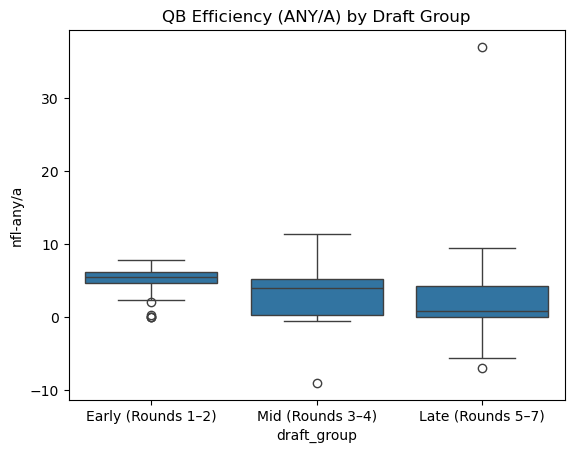

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='draft_group', y='nfl-any/a')
plt.title("QB Efficiency (ANY/A) by Draft Group")
plt.show()

In [ ]:
Early-round QBs show a higher median ANY/A, but there is significant overlap across groups.

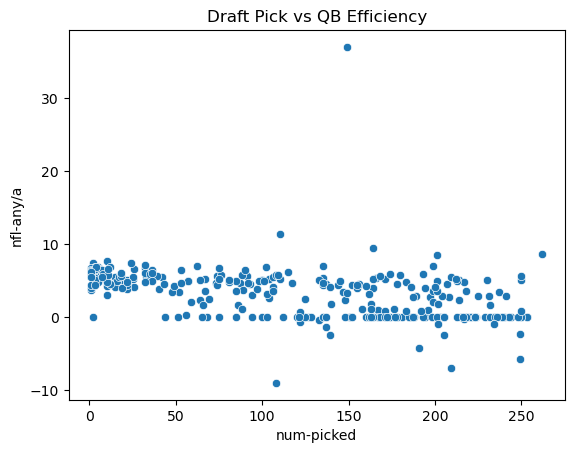

In [15]:
sns.scatterplot(data=df, x='num-picked', y='nfl-any/a')
plt.title("Draft Pick vs QB Efficiency")
plt.show()

In [ ]:
There is a slight downward trend, suggesting earlier picks perform better,
but variability is high.

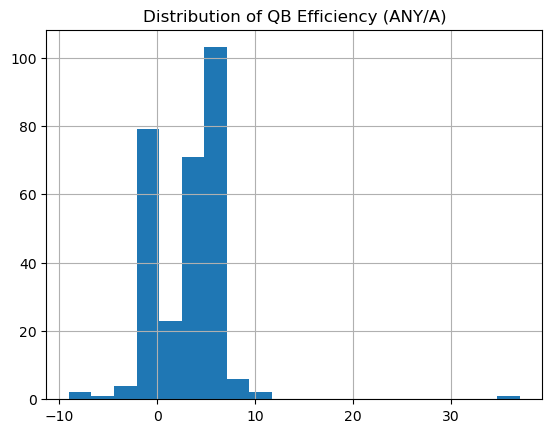

In [16]:
df['nfl-any/a'].hist(bins=20)
plt.title("Distribution of QB Efficiency (ANY/A)")
plt.show()

In [ ]:
QB efficiency is roughly normally distributed with some high-performing outliers.

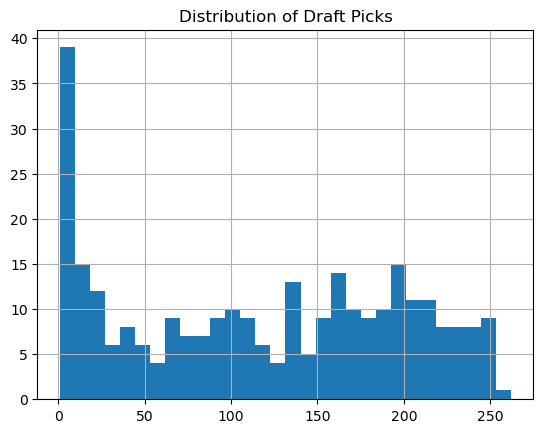

In [17]:
df['num-picked'].hist(bins=30)
plt.title("Distribution of Draft Picks")
plt.show()

In [ ]:
Most quarterbacks are selected in later rounds, creating a skewed distribution.

In [18]:
df[['num-picked', 'nfl-any/a', 'nfl-y/a', 'nfl-succ%']].corr()

,num-picked,nfl-any/a,nfl-y/a,nfl-succ%
num-picked,1.000000,-0.429160,-0.413491,-0.496619
nfl-any/a,-0.429160,1.000000,0.877128,0.741112
nfl-y/a,-0.413491,0.877128,1.000000,0.905546
nfl-succ%,-0.496619,0.741112,0.905546,1.000000


In [ ]:
There is a weak negative correlation between draft pick and ANY/A,
suggesting earlier picks tend to perform slightly better, but the relationship is not strong.

In [ ]:
## Key Findings

- Early-round quarterbacks tend to have higher average efficiency (ANY/A)
- However, the difference is not large, and variability is high
- Many late-round quarterbacks perform similarly or better than early picks

### Final Conclusion:
Draft position has some predictive value, but it is not a strong determinant
of NFL quarterback success.